<a href="https://colab.research.google.com/github/Deepika-S6/AI-GPU-Internship/blob/main/Fake_Internship_Offer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("internship_offers.csv")
df.head()

,offer_text,label
0,Software engineering internship for students w...,genuine
1,"Data analyst internship requiring Excel, SQL, ...",genuine
2,Machine learning internship with tasks in prep...,genuine
3,Web development internship for React and Node....,genuine
4,"Cloud computing internship with AWS basics, Li...",genuine


In [ ]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   offer_text  30 non-null     object
 1   label       30 non-null     object
dtypes: object(2)
memory usage: 612.0+ bytes


,0
offer_text,0
label,0


In [ ]:
df = df.dropna()

In [ ]:
X = df["offer_text"]

y = df["label"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model=Pipeline([
    ("tfidf",
     TfidfVectorizer(
         stop_words="english",
         ngram_range=(1,2)
     )),
    ("clf",
     LogisticRegression(
         max_iter=1000,
         class_weight="balanced"
     ))
])

In [ ]:
model.fit(X_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred=model.predict(X_test)

y_prob=model.predict_proba(X_test)[:,1]

In [ ]:
accuracy=accuracy_score(y_test,y_pred)

precision=precision_score(y_test,y_pred,pos_label="suspicious")

recall=recall_score(y_test,y_pred,pos_label="suspicious")

f1=f1_score(y_test,y_pred,pos_label="suspicious")

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 Score :",f1)

Accuracy : 0.8333333333333334
Precision : 0.75
Recall : 1.0
F1 Score : 0.8571428571428571


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

     genuine       1.00      0.67      0.80         3
  suspicious       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



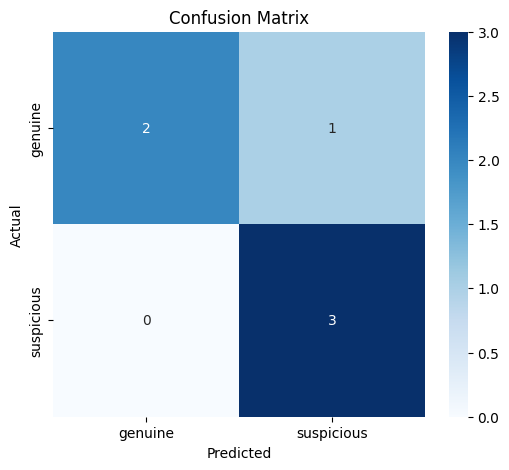

In [ ]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

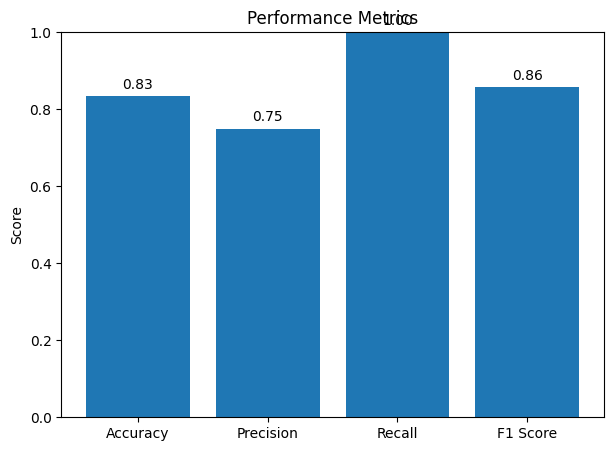

In [ ]:
metrics={
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1 Score":f1
}

plt.figure(figsize=(7,5))

plt.bar(metrics.keys(),metrics.values())

plt.ylim(0,1)

plt.title("Performance Metrics")

plt.ylabel("Score")

for i,v in enumerate(metrics.values()):
    plt.text(i,v+0.02,f"{v:.2f}",ha="center")

plt.show()

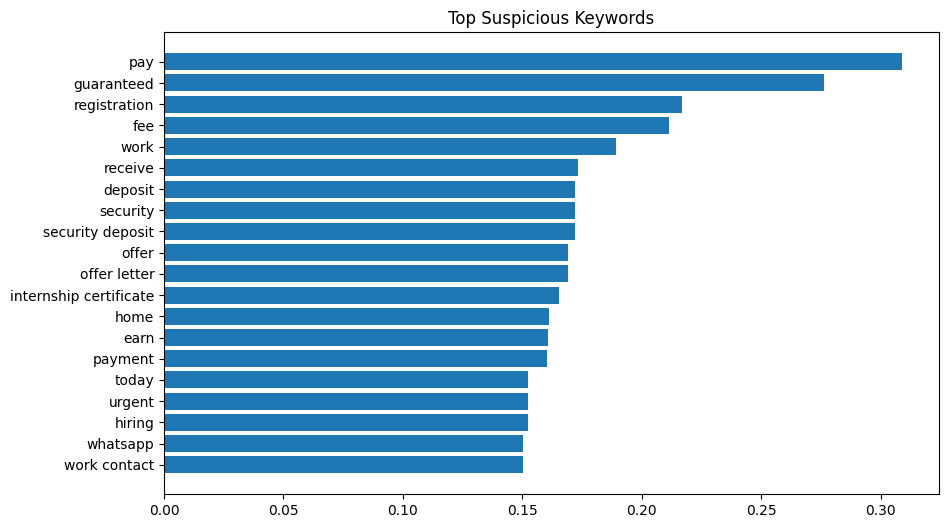

In [ ]:
vectorizer=model.named_steps["tfidf"]

classifier=model.named_steps["clf"]

feature_names=np.array(vectorizer.get_feature_names_out())

coef=classifier.coef_[0]

top_positive=np.argsort(coef)[-20:]

plt.figure(figsize=(10,6))

plt.barh(feature_names[top_positive],coef[top_positive])

plt.title("Top Suspicious Keywords")

plt.show()

In [ ]:
sample="""
Urgent hiring.

No interview.

Pay registration fee 999.

Guaranteed internship.

Contact through WhatsApp.
"""

prediction=model.predict([sample])[0]

confidence=model.predict_proba([sample]).max()

print("Prediction :",prediction)

print("Confidence :",confidence)

Prediction : suspicious
Confidence : 0.6144952381676108
